In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize


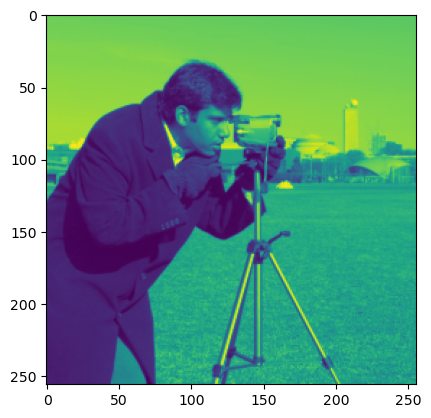

In [19]:
image = data.camera()
image = resize(image, (256, 256))  # Resize for faster FFT (optional)
plt.imshow(image)
M, N = image.shape  # Get image size

In [6]:
# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)



In [14]:
# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Laplacian spectrum
lapSpec = np.log(1 + np.abs(F_lap))

In [ ]:
###Original image
plt.imshow(image, cmap='gray')

In [ ]:
###Laplacian Spectrum
plt.imshow(lapSpec, cmap='gray')

In [ ]:
###Laplacian Spatial
plt.imshow(laplacian_image, cmap='gray')    

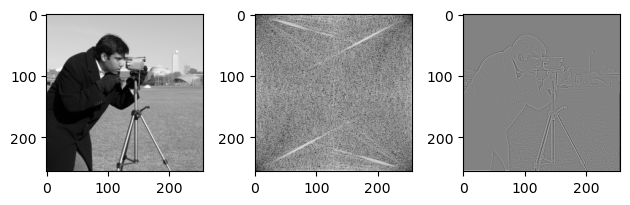

In [18]:
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(lapSpec, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')

plt.tight_layout()
plt.show()
 
